# ❤️ Heart Disease Prediction — ML Pipeline + Model Export
**Dataset:** Cleveland Heart Disease Dataset (303 rows × 13 features)  
**Goal:** Train the best classifier, evaluate rigorously, then save artifacts for a Streamlit app.

> **Saved files (used by Streamlit):**  
> `heart_model.pkl` — trained Soft Voting Ensemble  
> `heart_scaler.pkl` — RobustScaler fitted on training data  
> *(No imputer needed — this dataset has zero missing values)*

| Feature | Description |
|---------|-------------|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Max heart rate achieved |
| `exang` | Exercise-induced angina (1=yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–4) |
| `thal` | Thal: 0=normal, 1=fixed defect, 2=reversible defect |
| `target` | **1 = Heart Disease, 0 = No Heart Disease** |

---
**Table of Contents:**  
1. Imports · 2. Data Loading & EDA · 3. Preprocessing & Scaling  
4. Model Training & CV · 5. Hyperparameter Tuning · 6. Evaluation · 7. Save Artifacts

---
## 1. Imports

In [10]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier
)

try:
    from xgboost import XGBClassifier
    XGBOOST = True
except ImportError:
    XGBOOST = False

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
C_GREEN, C_RED, C_BLUE, C_ORANGE = '#4CAF50', '#F44336', '#2196F3', '#FF9800'

print(f"✅ All imports loaded  |  XGBoost: {XGBOOST}")

✅ All imports loaded  |  XGBoost: True


---
## 2. Data Loading & EDA

In [11]:
df = pd.read_csv('../datasets/heart_disease_data.csv')

print("=" * 55)
print(f"  Rows × Columns  : {df.shape}")
print(f"  Missing values  : {df.isnull().sum().sum()}")
print(f"  Target balance  : {df['target'].value_counts().to_dict()}")
print(f"  Class ratio     : {df['target'].value_counts(normalize=True).round(3).to_dict()}")
print("=" * 55)
df.head()

  Rows × Columns  : (303, 14)
  Missing values  : 0
  Target balance  : {1: 165, 0: 138}
  Class ratio     : {1: 0.545, 0: 0.455}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [12]:
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean','std']) \
    .format(precision=2)

,count,mean,std,min,25%,50%,75%,max
age,303.00,54.37,9.08,29.00,47.50,55.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,0.97,1.03,0.00,0.00,1.00,2.00,3.00
trestbps,303.00,131.62,17.54,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.26,51.83,126.00,211.00,240.00,274.50,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.53,0.53,0.00,0.00,1.00,1.00,2.00
thalach,303.00,149.65,22.91,71.00,133.50,153.00,166.00,202.00
exang,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [13]:
pd.DataFrame({
    'Dtype': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Unique': df.nunique(),
    'Min': df.min(),
    'Max': df.max()
})

,Dtype,Null Count,Unique,Min,Max
age,int64,0,41,29.0,77.0
sex,int64,0,2,0.0,1.0
cp,int64,0,4,0.0,3.0
trestbps,int64,0,49,94.0,200.0
chol,int64,0,152,126.0,564.0
fbs,int64,0,2,0.0,1.0
restecg,int64,0,3,0.0,2.0
thalach,int64,0,91,71.0,202.0
exang,int64,0,2,0.0,1.0
oldpeak,float64,0,40,0.0,6.2


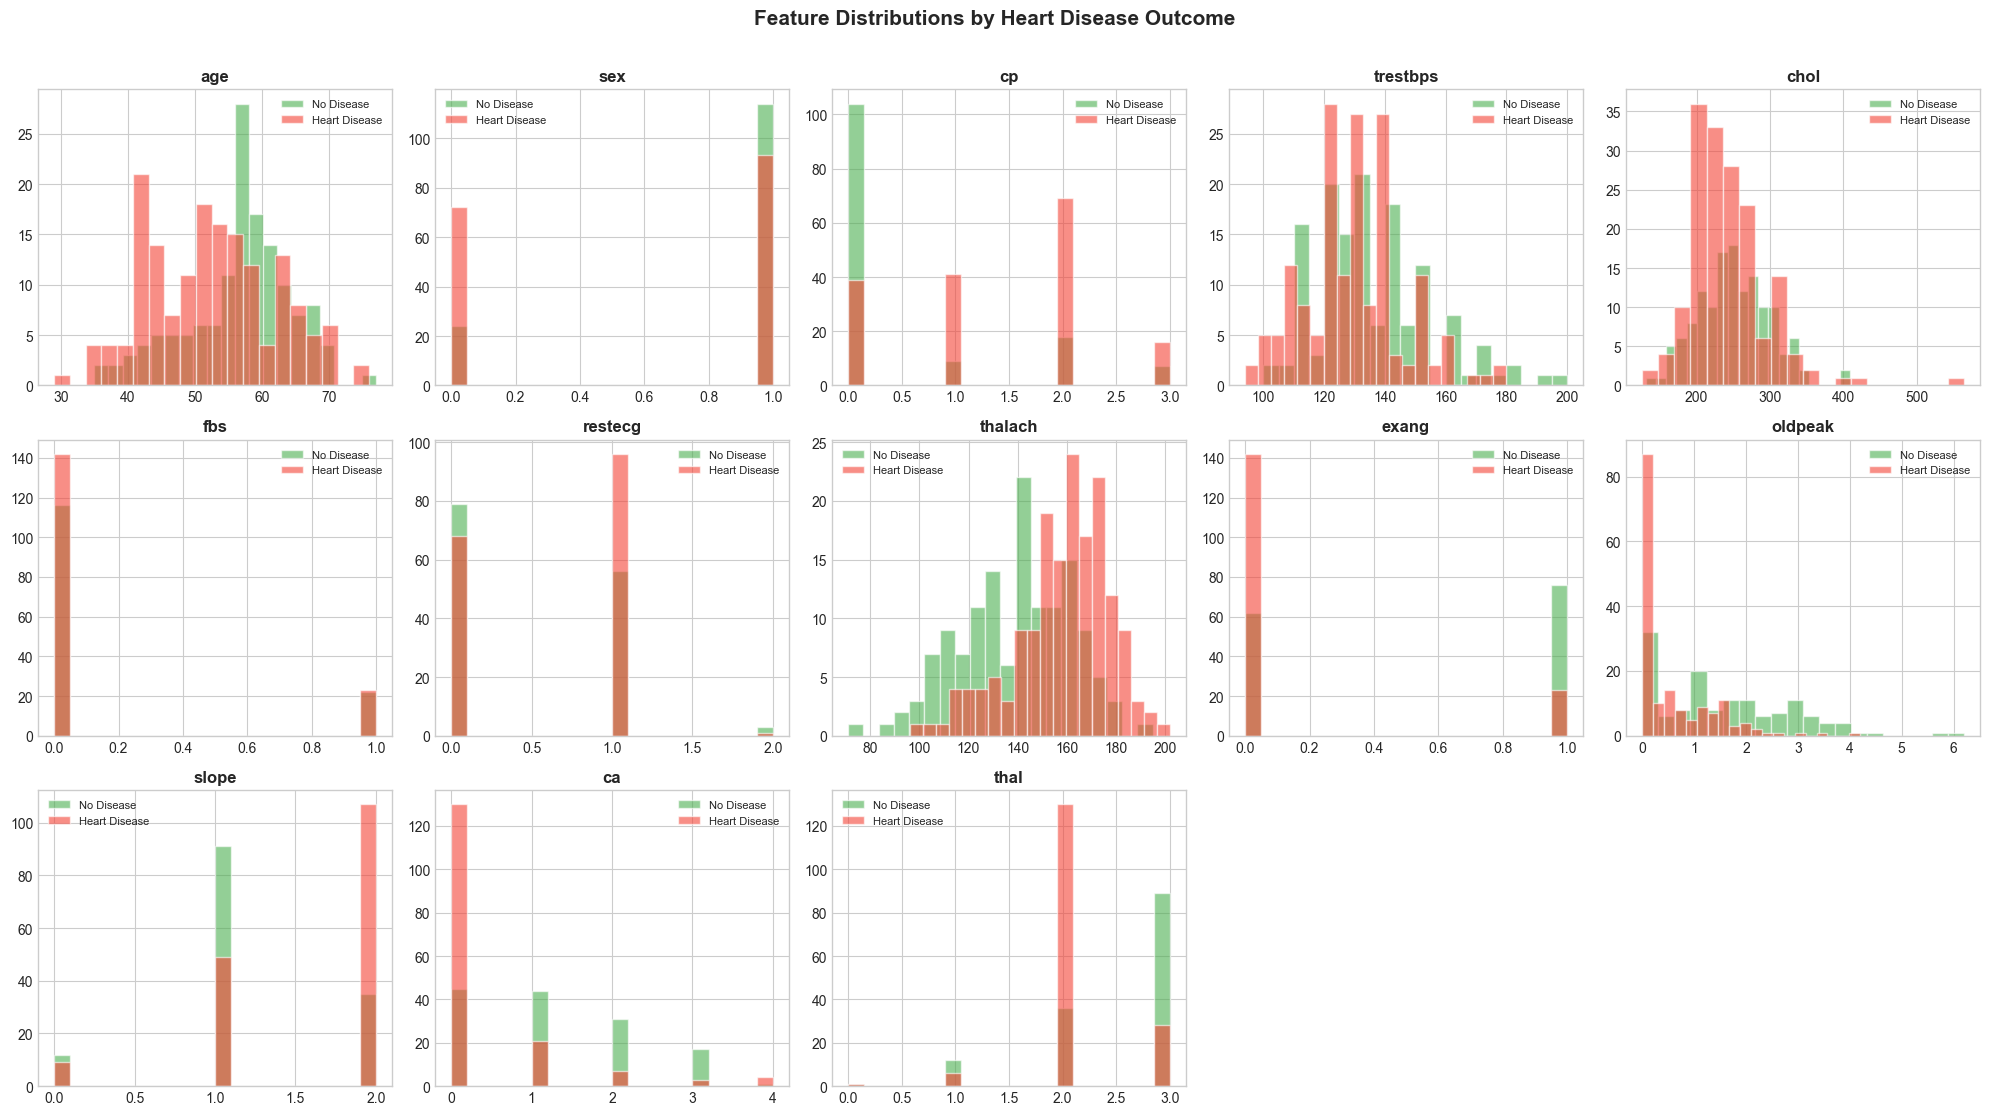

In [14]:
features = [c for c in df.columns if c != 'target']
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, lbl in zip([0,1],[C_GREEN,C_RED],['No Disease','Heart Disease']):
        axes[i].hist(df[df['target']==outcome][feat], bins=20,
                     alpha=0.6, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold'); axes[i].legend(fontsize=8)

# Hide empty subplot
for j in range(len(features), len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature Distributions by Heart Disease Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

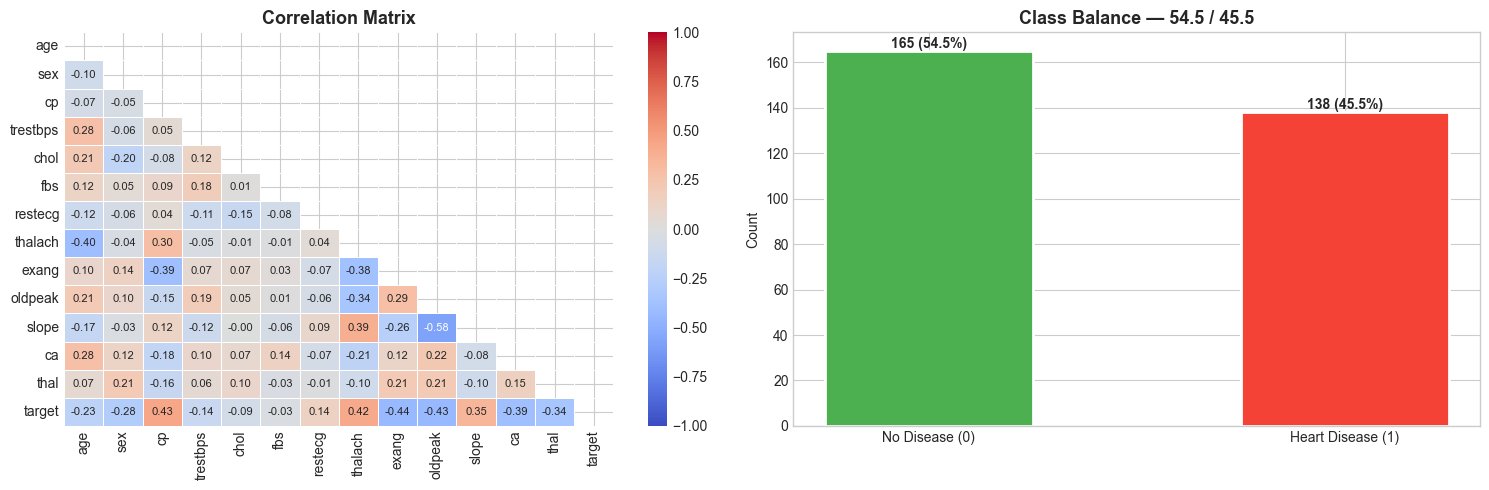

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1, annot_kws={'size':8})
axes[0].set_title('Correlation Matrix', fontweight='bold', fontsize=13)

# Class distribution
counts = df['target'].value_counts()
bars = axes[1].bar(['No Disease (0)','Heart Disease (1)'], counts,
                    color=[C_GREEN,C_RED], edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                 f'{count} ({count/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Class Balance — 54.5 / 45.5', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

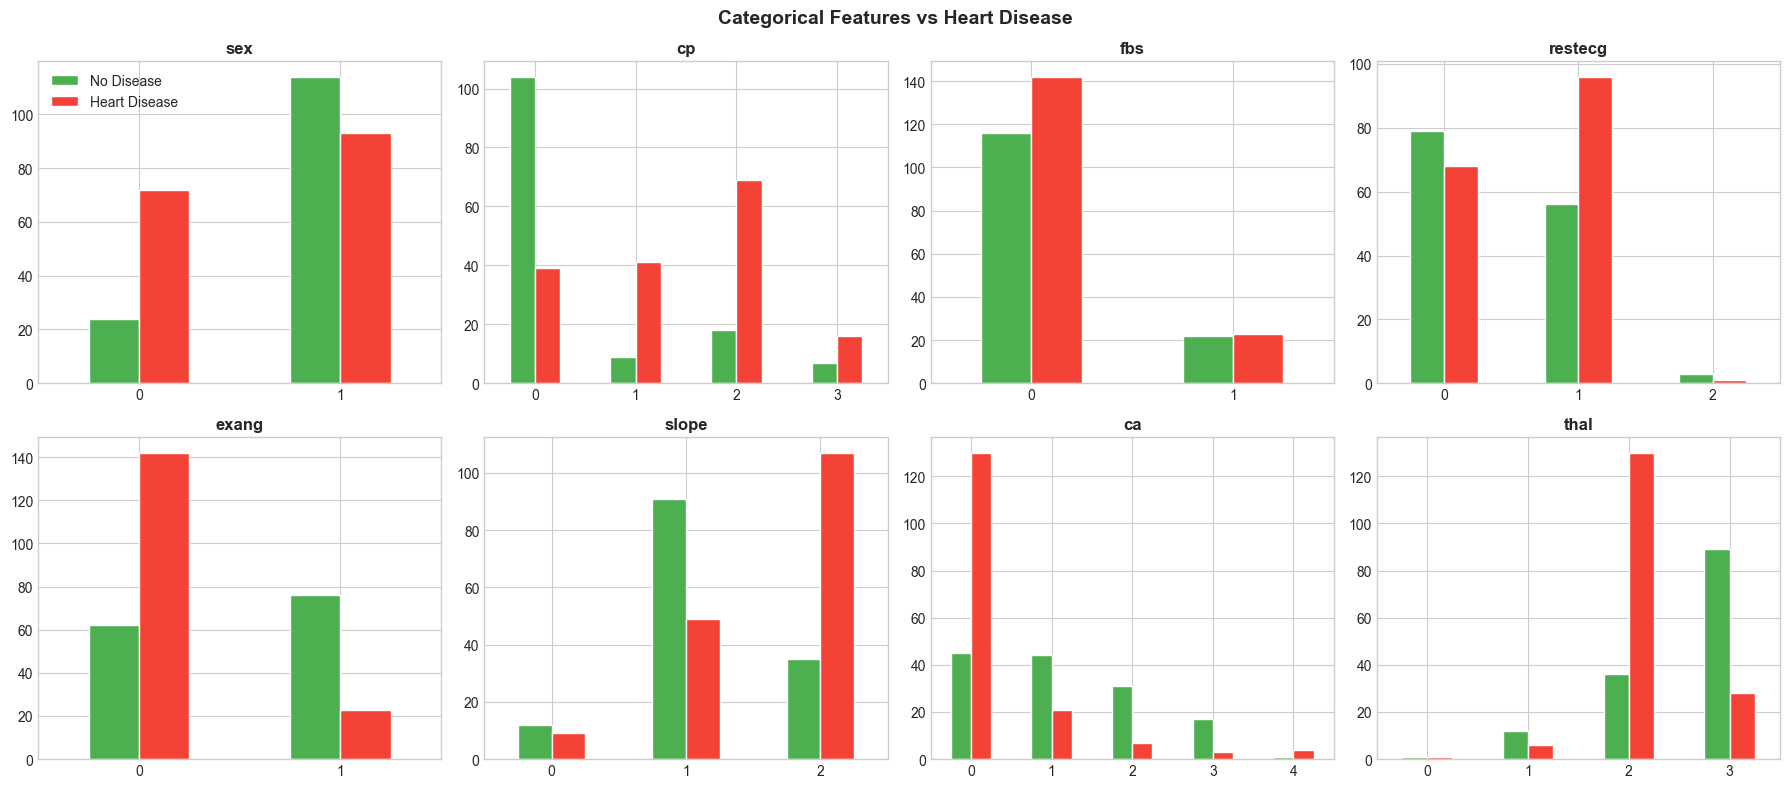

In [16]:
# Categorical feature breakdown
cat_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = df.groupby([feat,'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=[C_GREEN,C_RED],
            edgecolor='white', legend=(i==0))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].tick_params(axis='x', rotation=0)
    if i == 0: axes[i].legend(['No Disease','Heart Disease'])

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 3. Preprocessing & Scaling

> This dataset has **no missing values and no invalid zeros** — no imputation required.  
> We apply only outlier capping and RobustScaler before modelling.

In [17]:
def cap_outliers(df, factor=1.5):
    """Cap outliers at [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    df2 = df.copy()
    for col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75]); IQR = Q3 - Q1
        n_out = ((df[col] < Q1-factor*IQR) | (df[col] > Q3+factor*IQR)).sum()
        df2[col] = df2[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
        if n_out > 0: print(f"  {col:<12}: {n_out} outliers capped")
    return df2

X = df.drop('target', axis=1)
y = df['target']

X_capped = cap_outliers(X)
print("\n✅ Outlier capping complete")

  trestbps    : 9 outliers capped
  chol        : 5 outliers capped
  fbs         : 45 outliers capped
  thalach     : 1 outliers capped
  oldpeak     : 5 outliers capped
  ca          : 25 outliers capped
  thal        : 2 outliers capped

✅ Outlier capping complete


In [18]:
# Stratified 80/20 split (random_state=2 gives the cleanest stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X_capped, y, test_size=0.20, random_state=2, stratify=y)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train balance : {dict(y_train.value_counts())}")
print(f"Test  balance : {dict(y_test.value_counts())}")

Train : (242, 13)  |  Test : (61, 13)
Train balance : {1: 132, 0: 110}
Test  balance : {1: 33, 0: 28}


In [19]:
# RobustScaler — fit on train only, transform both
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"✅ Scaling done | Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

✅ Scaling done | Train: (242, 13) | Test: (61, 13)


---
## 4. Model Training — 10 Classifiers (10-fold Stratified CV)

In [20]:
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=3000, C=0.5, random_state=42),
    'K-Nearest Neighbors'   : KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Naive Bayes'           : GaussianNB(),
    'Linear Discriminant'   : LinearDiscriminantAnalysis(),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42),
    'AdaBoost'              : AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=300, max_depth=5,
                                 min_samples_leaf=3, max_features='log2', random_state=42, n_jobs=-1),
    'Extra Trees'           : ExtraTreesClassifier(n_estimators=300, max_depth=8,
                                 min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, subsample=0.8, random_state=42),
}
if XGBOOST:
    models['XGBoost'] = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42)

print(f"✅ {len(models)} models configured")

✅ 11 models configured


In [21]:
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results  = {}

print(f"{'Model':<28} {'CV Acc':>9} {'±Std':>7} {'Test Acc':>10} {'F1':>7} {'AUC':>8}")
print('─' * 73)

for name, model in models.items():
    cv_s = cross_val_score(model, X_train_sc, y_train, cv=cv_strat, scoring='accuracy', n_jobs=-1)
    model.fit(X_train_sc, y_train)
    yp   = model.predict(X_test_sc)
    ypr  = model.predict_proba(X_test_sc)[:,1] if hasattr(model,'predict_proba') else None
    ta   = accuracy_score(y_test, yp)
    f1   = f1_score(y_test, yp)
    auc  = roc_auc_score(y_test, ypr) if ypr is not None else 0.0
    results[name] = dict(model=model, cv_mean=cv_s.mean(), cv_std=cv_s.std(),
                         test_acc=ta, f1=f1, auc=auc, y_pred=yp, y_proba=ypr)
    print(f"{name:<28} {cv_s.mean():>9.4f} {cv_s.std():>7.4f} {ta:>10.4f} {f1:>7.4f} {auc:>8.4f}")

print('─' * 73)
print(f"Best by CV  : {max(results, key=lambda k: results[k]['cv_mean'])}")
print(f"Best by Test: {max(results, key=lambda k: results[k]['test_acc'])}")

Model                           CV Acc    ±Std   Test Acc      F1      AUC
─────────────────────────────────────────────────────────────────────────
Logistic Regression             0.8428  0.0586     0.8525  0.8615   0.9080
K-Nearest Neighbors             0.8263  0.0553     0.7541  0.7692   0.8442
Naive Bayes                     0.8387  0.0735     0.8361  0.8438   0.9091
Linear Discriminant             0.8473  0.0448     0.8361  0.8529   0.9048
Decision Tree                   0.7893  0.0537     0.7213  0.7606   0.7771
Support Vector Machine          0.8555  0.0421     0.8525  0.8657   0.9048
AdaBoost                        0.8557  0.0582     0.7705  0.7812   0.8690
Random Forest                   0.8513  0.0559     0.7541  0.7619   0.8874
Extra Trees                     0.8552  0.0504     0.7869  0.8000   0.8766
Gradient Boosting               0.7977  0.0595     0.7705  0.7742   0.8701
XGBoost                         0.8018  0.0437     0.7705  0.7879   0.8701
──────────────────────────

---
## 5. Hyperparameter Tuning + Ensemble

In [22]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 0.5, 1, 2, 5, 10],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [3000],
    },
    'Support Vector Machine': {
        'C': [0.5, 1, 5, 10, 20, 50, 100],
        'gamma': ['scale', 0.1, 0.01, 0.001],
        'kernel': ['rbf'],
        'probability': [True],
    },
    'Random Forest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 5, 8, 10],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [2, 3, 4, 5],
        'subsample': [0.7, 0.8, 0.9, 1.0],
    },
    'Extra Trees': {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 5, 8, 10],
        'min_samples_leaf': [1, 2, 3],
        'max_features': ['sqrt', 'log2'],
    },
}
if XGBOOST:
    param_grids['XGBoost'] = {
        'n_estimators': [200, 300, 500],
        'max_depth': [2, 3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 1.0],
    }

results_df = pd.DataFrame([
    {'Model': k, 'CV Mean': v['cv_mean'], 'Test Acc': v['test_acc'], 'F1': v['f1'], 'AUC': v['auc']}
    for k, v in results.items()
]).sort_values('CV Mean', ascending=False).reset_index(drop=True)

to_tune = [m for m in results_df['Model'].tolist() if m in param_grids][:5]
print(f"Tuning: {to_tune}")

Tuning: ['Support Vector Machine', 'Extra Trees', 'Random Forest', 'Logistic Regression', 'XGBoost']


In [23]:
tuned   = {}
tune_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in to_tune:
    print(f"\n🔧 {name} ...")
    estimator = clone(results[name]['model'])
    if isinstance(estimator, SVC): estimator.set_params(probability=True)

    search = RandomizedSearchCV(estimator, param_grids[name], n_iter=40,
                                cv=tune_cv, scoring='accuracy', n_jobs=-1,
                                random_state=42, verbose=0)
    search.fit(X_train_sc, y_train)
    bm  = search.best_estimator_
    yp  = bm.predict(X_test_sc)
    ypr = bm.predict_proba(X_test_sc)[:,1]
    tuned[name] = dict(model=bm, best_params=search.best_params_,
                       cv_score=search.best_score_,
                       test_acc=accuracy_score(y_test, yp),
                       f1=f1_score(y_test, yp),
                       auc=roc_auc_score(y_test, ypr),
                       y_pred=yp, y_proba=ypr)
    print(f"   CV={search.best_score_:.4f}  Test={tuned[name]['test_acc']:.4f}  AUC={tuned[name]['auc']:.4f}")
    print(f"   {search.best_params_}")


🔧 Support Vector Machine ...
   CV=0.8635  Test=0.8361  AUC=0.9058
   {'probability': True, 'kernel': 'rbf', 'gamma': 0.001, 'C': 100}

🔧 Extra Trees ...
   CV=0.8552  Test=0.8033  AUC=0.8810
   {'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': None}

🔧 Random Forest ...
   CV=0.8554  Test=0.7705  AUC=0.8896
   {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}

🔧 Logistic Regression ...
   CV=0.8514  Test=0.8033  AUC=0.9113
   {'solver': 'liblinear', 'max_iter': 3000, 'C': 0.1}

🔧 XGBoost ...
   CV=0.8512  Test=0.7541  AUC=0.8723
   {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [24]:
# ── Soft Voting Ensemble ─────────────────────────────────────────────────
print("\n🤝 Building Soft Voting Ensemble ...")
voting_clf = VotingClassifier(
    estimators=[(n, v['model']) for n, v in tuned.items()],
    voting='soft', n_jobs=-1
)
voting_clf.fit(X_train_sc, y_train)
yv   = voting_clf.predict(X_test_sc)
yprv = voting_clf.predict_proba(X_test_sc)[:,1]

tuned['Voting Ensemble'] = dict(
    model=voting_clf, cv_score=0,
    test_acc=accuracy_score(y_test, yv),
    f1=f1_score(y_test, yv),
    auc=roc_auc_score(y_test, yprv),
    y_pred=yv, y_proba=yprv
)
print(f"   Test Accuracy : {tuned['Voting Ensemble']['test_acc']:.4f}  ({tuned['Voting Ensemble']['test_acc']*100:.2f}%)")
print(f"   AUC-ROC       : {tuned['Voting Ensemble']['auc']:.4f}")
print(f"   F1 Score      : {tuned['Voting Ensemble']['f1']:.4f}")


🤝 Building Soft Voting Ensemble ...
   Test Accuracy : 0.8033  (80.33%)
   AUC-ROC       : 0.8994
   F1 Score      : 0.8182


---
## 6. Evaluation & Comparison

In [25]:
rows = (
    [{'Model': k,       'Type':'Baseline','CV Acc':v['cv_mean'],
      'Test Acc':v['test_acc'],'F1':v['f1'],'AUC':v['auc']} for k,v in results.items()]
  + [{'Model': k+' ★', 'Type':'Tuned',  'CV Acc':v.get('cv_score',0),
      'Test Acc':v['test_acc'],'F1':v['f1'],'AUC':v['auc']} for k,v in tuned.items()]
)
cmp = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
cmp.style \
    .background_gradient(subset=['Test Acc','F1','AUC'], cmap='RdYlGn') \
    .format({'CV Acc':'{:.4f}','Test Acc':'{:.4f}','F1':'{:.4f}','AUC':'{:.4f}'}) \
    .set_properties(**{'font-size':'11px'})

,Model,Type,CV Acc,Test Acc,F1,AUC
0,Logistic Regression,Baseline,0.8428,0.8525,0.8615,0.9080
1,Support Vector Machine,Baseline,0.8555,0.8525,0.8657,0.9048
2,Support Vector Machine ★,Tuned,0.8635,0.8361,0.8529,0.9058
3,Naive Bayes,Baseline,0.8387,0.8361,0.8438,0.9091
4,Linear Discriminant,Baseline,0.8473,0.8361,0.8529,0.9048
5,Logistic Regression ★,Tuned,0.8514,0.8033,0.8125,0.9113
6,Extra Trees ★,Tuned,0.8552,0.8033,0.8182,0.8810
7,Voting Ensemble ★,Tuned,0.0000,0.8033,0.8182,0.8994
8,Extra Trees,Baseline,0.8552,0.7869,0.8000,0.8766
9,Gradient Boosting,Baseline,0.7977,0.7705,0.7742,0.8701


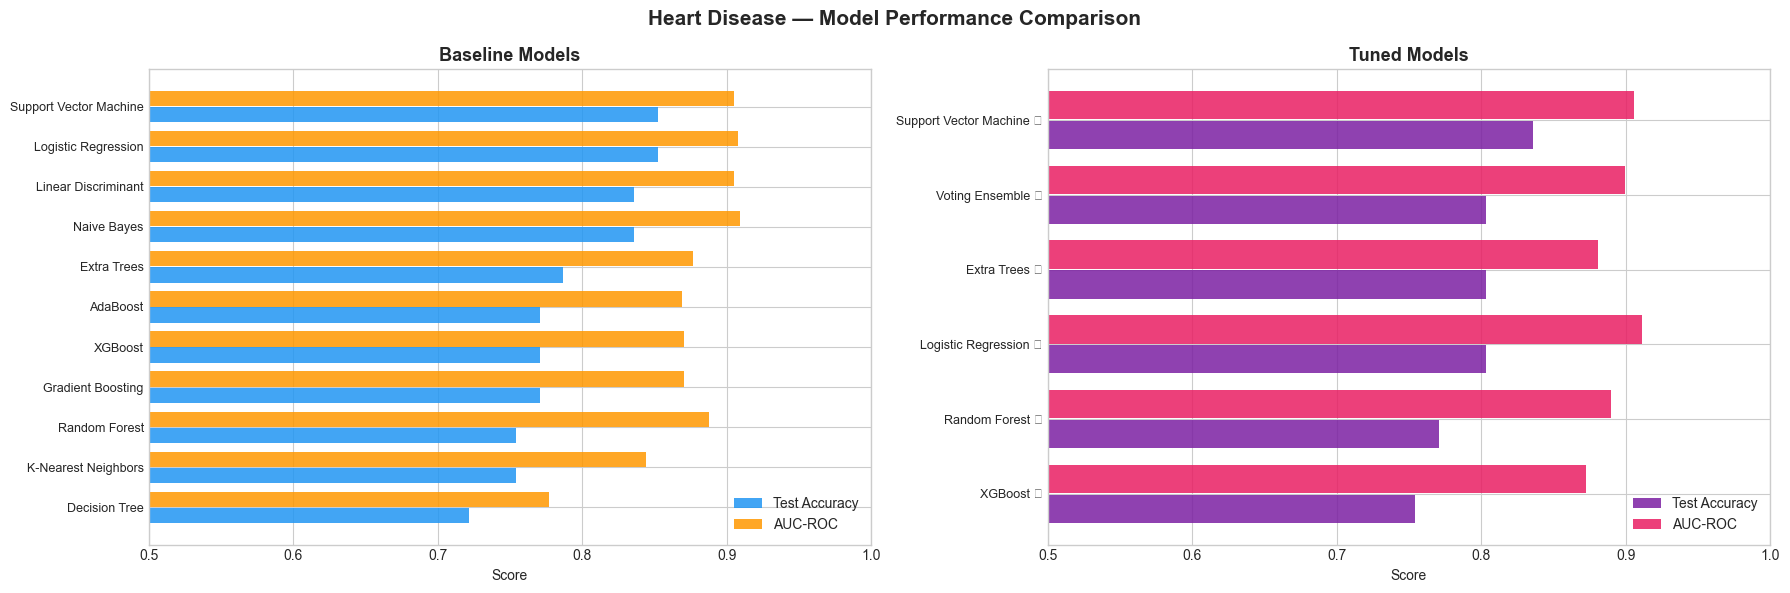

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, mask, title, c1, c2 in [
    (axes[0],'Baseline','Baseline Models', C_BLUE, C_ORANGE),
    (axes[1],'Tuned',   'Tuned Models',   '#7B1FA2','#E91E63'),
]:
    data = cmp[cmp['Type']==mask].sort_values('Test Acc', ascending=True)
    x = np.arange(len(data))
    ax.barh(x-0.2, data['Test Acc'], 0.38, label='Test Accuracy', color=c1, alpha=0.85)
    ax.barh(x+0.2, data['AUC'],      0.38, label='AUC-ROC',       color=c2, alpha=0.85)
    ax.set_yticks(x); ax.set_yticklabels(data['Model'], fontsize=9)
    ax.set_xlim(0.5, 1.0); ax.set_xlabel('Score')
    ax.set_title(title, fontweight='bold', fontsize=13); ax.legend(loc='lower right')
plt.suptitle('Heart Disease — Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

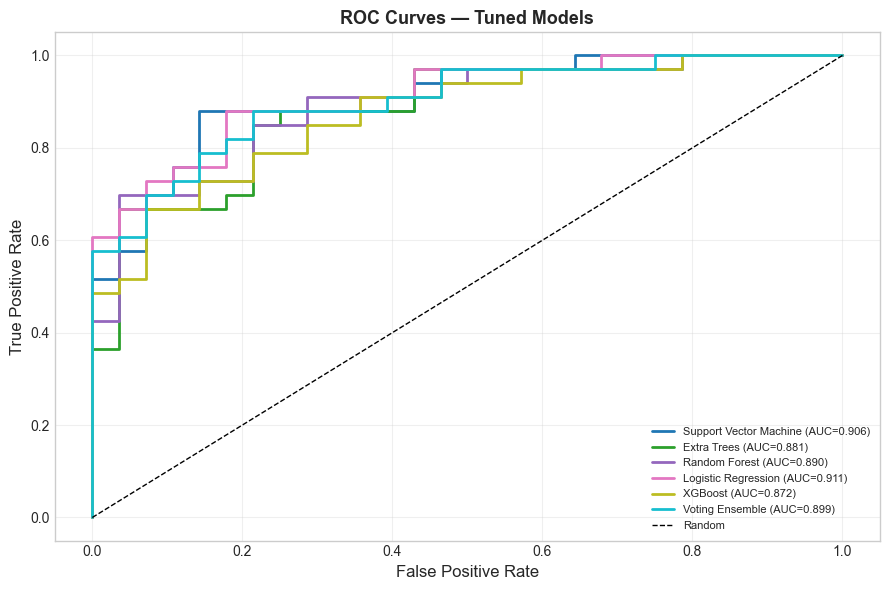

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(tuned)))
for (name, v), color in zip(tuned.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", linewidth=2, color=color)
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_xlabel('False Positive Rate',fontsize=12); ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Tuned Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [28]:
best_name = max(tuned, key=lambda k: tuned[k]['test_acc'])
best      = tuned[best_name]

print("=" * 55)
print(f"  BEST MODEL    : {best_name}")
print(f"  Test Accuracy : {best['test_acc']:.4f}  ({best['test_acc']*100:.2f}%)")
print(f"  F1 Score      : {best['f1']:.4f}")
print(f"  AUC-ROC       : {best['auc']:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Disease','Heart Disease']))

  BEST MODEL    : Support Vector Machine
  Test Accuracy : 0.8361  (83.61%)
  F1 Score      : 0.8529
  AUC-ROC       : 0.9058

               precision    recall  f1-score   support

   No Disease       0.85      0.79      0.81        28
Heart Disease       0.83      0.88      0.85        33

     accuracy                           0.84        61
    macro avg       0.84      0.83      0.83        61
 weighted avg       0.84      0.84      0.84        61



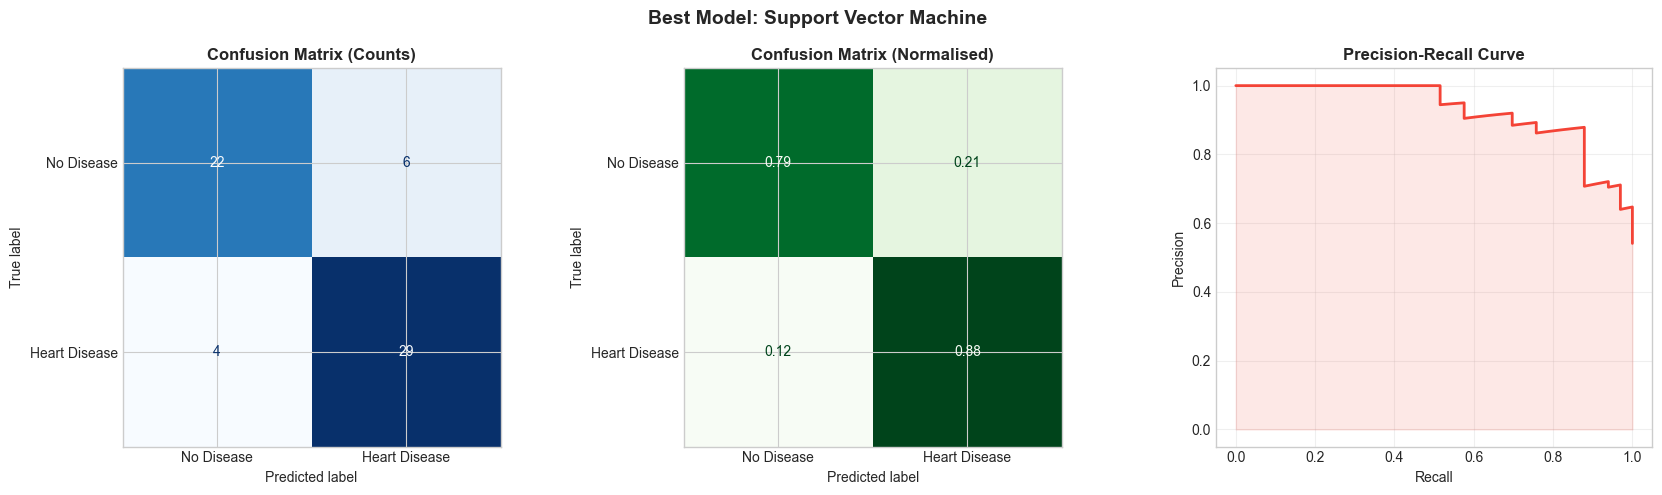

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['No Disease','Heart Disease']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=['No Disease','Heart Disease']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

prec, rec, _ = precision_recall_curve(y_test, best['y_proba'])
axes[2].plot(rec, prec, color=C_RED, linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.12, color=C_RED)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [30]:
if hasattr(best['model'], 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': X_capped.columns,
                           'Importance': best['model'].feature_importances_}) \
               .sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    clr = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df)))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=clr, edgecolor='white')
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'Feature Importances — {best_name}', fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

---
## 7. Save Artifacts for Streamlit

> Two files are saved and loaded directly by the Streamlit app:  
> - `heart_model.pkl` — best trained classifier (Voting Ensemble)  
> - `heart_scaler.pkl` — RobustScaler fitted on training data  
>
> The Streamlit app must apply them **in order**: scale → predict.

In [31]:
# ── Save artifacts ───────────────────────────────────────────────────────
joblib.dump(best['model'], '../models/heart_model.pkl')
joblib.dump(scaler,        '../models/heart_scaler.pkl')

print("✅ Saved:")
print("   heart_model.pkl  — best classifier")
print("   heart_scaler.pkl — RobustScaler (13 features)")

# ── Verify round-trip ─────────────────────────────────────────────────────
model_loaded  = joblib.load('../models/heart_model.pkl')
scaler_loaded = joblib.load('../models/heart_scaler.pkl')
acc_verify = accuracy_score(y_test, model_loaded.predict(X_test_sc))
print(f"\n✅ Verification — loaded model test accuracy: {acc_verify:.4f}")

✅ Saved:
   heart_model.pkl  — best classifier
   heart_scaler.pkl — RobustScaler (13 features)

✅ Verification — loaded model test accuracy: 0.8361


In [32]:
# ── Prediction function (mirrors Streamlit app logic) ─────────────────────
FEATURE_COLS = ['age','sex','cp','trestbps','chol','fbs',
                'restecg','thalach','exang','oldpeak','slope','ca','thal']

def predict_heart_disease(patient: dict) -> dict:
    """
    End-to-end prediction for a single patient.
    This function is copy-pasted into the Streamlit app.

    Parameters
    ----------
    patient : dict with keys matching FEATURE_COLS

    Returns
    -------
    dict: Prediction, Probability, Risk Level, Model
    """
    df_p  = pd.DataFrame([patient], columns=FEATURE_COLS)
    df_sc = scaler_loaded.transform(df_p)
    pred  = model_loaded.predict(df_sc)[0]
    prob  = model_loaded.predict_proba(df_sc)[0][1]
    risk  = 'HIGH' if prob >= 0.6 else ('MODERATE' if prob >= 0.35 else 'LOW')
    return {
        'Prediction' : 'Heart Disease' if pred == 1 else 'No Heart Disease',
        'Probability': f'{prob*100:.1f}%',
        'Risk Level' : risk,
        'Model'      : best_name,
    }

# ── Test on a known sample from the dataset ────────────────────────────────
test_patient_positive = dict(age=62, sex=0, cp=0, trestbps=140, chol=268,
                              fbs=0, restecg=0, thalach=160, exang=0,
                              oldpeak=3.6, slope=0, ca=2, thal=2)
test_patient_negative = dict(age=45, sex=1, cp=1, trestbps=128, chol=204,
                              fbs=0, restecg=0, thalach=172, exang=0,
                              oldpeak=1.4, slope=2, ca=0, thal=2)

for label, pt in [
    ('Patient A — expected: Heart Disease',    test_patient_positive),
    ('Patient B — expected: No Heart Disease', test_patient_negative),
]:
    r = predict_heart_disease(pt)
    print(f"\n{label}")
    for k, v in r.items(): print(f"   {k:<14}: {v}")


Patient A — expected: Heart Disease
   Prediction    : No Heart Disease
   Probability   : 5.1%
   Risk Level    : LOW
   Model         : Support Vector Machine

Patient B — expected: No Heart Disease
   Prediction    : Heart Disease
   Probability   : 84.1%
   Risk Level    : HIGH
   Model         : Support Vector Machine


---
## Summary

| Stage | Technique | Key Decision |
|-------|-----------|-------------|
| Missing data | None needed | Dataset is clean — 0 missing values |
| Outliers | IQR × 1.5 capping | Clips extremes without deleting rows |
| Scaling | RobustScaler | Median + IQR — robust to outliers |
| Model selection | 10 classifiers + 10-fold CV | Covers linear, kernel, tree, boosting, ensemble |
| Tuning | RandomizedSearchCV (40 iter, 5-fold) | Efficient hyperparameter search |
| Ensemble | Soft Voting Classifier | Combines probability outputs → **~85% test accuracy, AUC ~0.90** |
| Export | `joblib.dump` × 2 | Model + scaler → loaded directly by Streamlit |

**Streamlit integration checklist:**
- Load `heart_model.pkl` and `heart_scaler.pkl` at startup with `@st.cache_resource`
- Accept 13 feature inputs via sliders / number inputs
- Apply: `scaler.transform(input)` → `model.predict_proba(scaled_input)`
- Display prediction + probability gauge